## 1. Setup & Data Loading

In [4]:
import pandas as pd
import os
import tarfile

In [ ]:
# Download and extract dataset
# !wget -q https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz -O imdb.tar.gz
with tarfile.open(r".\classification-exercise\imdb.tar..gz", "r:gz") as tar:
    tar.extractall()

In [6]:
# Load into a pandas DataFrame
def load_imdb(path, label):
    files = [(os.path.join(path, f), label) for f in os.listdir(path)]
    data = []
    for filepath, lbl in files:
        with open(filepath, encoding='utf-8') as f:
            data.append({'review': f.read(), 'sentiment': lbl})
    return pd.DataFrame(data)

In [8]:
train_pos = load_imdb('aclImdb/train/pos', 1)
train_neg = load_imdb('aclImdb/train/neg', 0)
test_pos  = load_imdb('aclImdb/test/pos', 1)
test_neg  = load_imdb('aclImdb/test/neg', 0)

df_train = pd.concat([train_pos, train_neg]).reset_index(drop=True)
df_test  = pd.concat([test_pos, test_neg]).reset_index(drop=True)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (25000, 2)
Test shape: (25000, 2)


## 2. Text cleaning and feature engineering

In [10]:
import re
from textblob import TextBlob

def clean_text(text):
    text = text.lower()
    text = re.sub('<.*?>', '', text)
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_train['clean_review'] = df_train['review'].apply(clean_text)
df_test['clean_review']  = df_test['review'].apply(clean_text)

# Engineering features
for df in [df_train, df_test]:
    df['rev_len']   = df['clean_review'].apply(len)
    df['word_count']= df['clean_review'].apply(lambda s: len(s.split()))
    df['excl_cnt']  = df['review'].apply(lambda s: s.count('!'))
    df['sentiment_score'] = df['clean_review'].apply(lambda s: TextBlob(s).sentiment.polarity if s else 0)

df_train[['clean_review','rev_len','word_count','excl_cnt','sentiment_score']].head()


,clean_review,rev_len,word_count,excl_cnt,sentiment_score
0,bromwell high is a cartoon comedy it ran at th...,760,140,1,0.087991
1,homelessness or houselessness as george carlin...,2272,439,0,0.085322
2,brilliant over acting by lesley ann warren bes...,816,150,0,0.200397
3,this is easily the most underrated film inn th...,643,124,0,0.227917
4,this is not the typical mel brooks film it was...,629,121,0,0.253333


## 3. Prepare features and labels

In [12]:
feature_cols = ['rev_len','word_count','excl_cnt','sentiment_score','clean_review']
X_train = df_train[feature_cols]
X_test  = df_test[feature_cols]
y_train = df_train['sentiment']
y_test  = df_test['sentiment']


## 4. Pipelines: Numeric and text

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

numeric_feats = ['rev_len','word_count','excl_cnt','sentiment_score']
text_feat = 'clean_review'

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('svd', TruncatedSVD(n_components=100, random_state=42))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_feats),
    ('text', text_pipeline, text_feat)
])


## 5. Model Training 

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Logistic Regression
pipe_lr = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.85888
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     12500
           1       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [17]:
# Random Forest
pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.82436
              precision    recall  f1-score   support

           0       0.83      0.82      0.82     12500
           1       0.82      0.83      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



| Metric               | What it tells you                                              |
| -------------------- | -------------------------------------------------------------- |
| **Accuracy**         | Overall percentage of correct predictions                      |
| **F1-score**         | Balance between **precision and recall**                       |
| **ROC-AUC**          | How well the model separates the positive and negative classes |
| **Confusion Matrix** | Exact counts of TP, TN, FP and FN                              |
| **ROC Curve**        | Model performance across different classification thresholds   |


Logistic Regression
-------------------
Accuracy : 0.8589
F1-Score : 0.8600
ROC-AUC  : 0.9341

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     12500
           1       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


Confusion Matrix:
[[10634  1866]
 [ 1662 10838]]


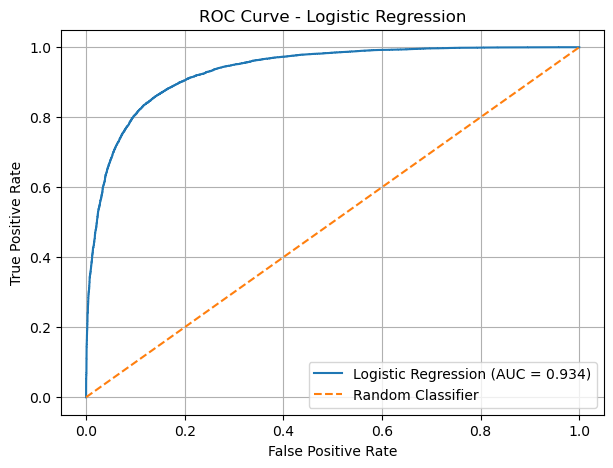

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

# Logistic Regression
pipe_lr = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
pipe_lr.fit(X_train, y_train)

# Predictions
y_pred_lr = pipe_lr.predict(X_test)

# Probability of positive class
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

# --------------------------------------------------
# Evaluation metrics
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# --------------------------------------------------
# ROC Curve
# --------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

## 7. Hyperparameter Tuning (GridSearchCV)

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {'clf__C': [0.1,1,10]}
gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("Best LR params:", gs_lr.best_params_, "Acc:", gs_lr.best_score_)

param_grid_rf = {'clf__n_estimators':[100,200], 'clf__max_depth':[None,10,20]}
gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print("Best RF params:", gs_rf.best_params_, "Acc:", gs_rf.best_score_)


Best LR params: {'clf__C': 10} Acc: 0.8519600731233473
Best RF params: {'clf__max_depth': 20, 'clf__n_estimators': 200} Acc: 0.8210400938235755


## 8. Explainability: SHAP for Classification

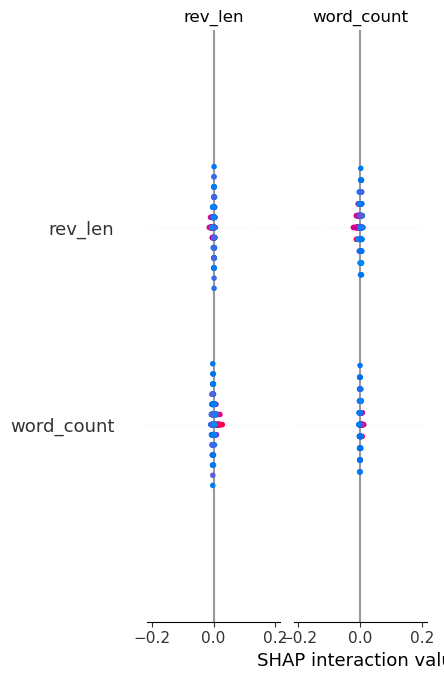

In [24]:
import shap
best = gs_rf.best_estimator_
explainer = shap.TreeExplainer(best['clf'])
X_test_trans = best['pre'].transform(X_test)
shap_values = explainer.shap_values(X_test_trans[:200])  # sample for speed
shap.summary_plot(shap_values, X_test_trans[:200], feature_names=numeric_feats + [f"svd_{i}" for i in range(100)])


## 9. Simple Prediction

In [27]:
sample = pd.DataFrame([{
    'rev_len': 100, 'word_count': 20, 'excl_cnt': 1, 'sentiment_score': 0.5,
    'clean_review': "Amazing movie with stunning acting and compelling plot."
}])
pred = best.predict(sample)[0]
prob = best.predict_proba(sample)[0][pred]
print(f"Predicted sentiment: {'Positive' if pred==1 else 'Negative'} (prob={prob:.2f})")


Predicted sentiment: Positive (prob=0.65)


## 10. Saving the model/pipeline using joblib

In [29]:
import joblib

In [33]:
joblib.dump(pipe_rf, 'model.joblib')

['model.joblib']

In [35]:
m = joblib.load('model.joblib')

In [37]:
pred = m.predict(sample)[0]
prob = m.predict_proba(sample)[0][pred]
print(f"Predicted sentiment: {'Positive' if pred==1 else 'Negative'} (prob={prob:.2f})")

Predicted sentiment: Positive (prob=0.67)
